# Heteroscedasticidad

## Cuestiones

In [20]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pylab as plt
#!pip install wooldridge
from wooldridge import *

1. Usando los datos de **sleep75**, analizar la posible existencia de heteroscedasticidad en el modelo $
sleep = \beta_0 + \beta_1 totwrk + \beta_2 educ + \beta_3 age + \beta_4 age^2 + \beta_5 yngkid + u$



$H_0:$ EL MODELO ES HOMOCEDASTICO

In [3]:
dataWoo("sleep75", description=True)

name of dataset: sleep75
no of variables: 34
no of observations: 706

+----------+--------------------------------+
| variable | label                          |
+----------+--------------------------------+
| age      | in years                       |
| black    | =1 if black                    |
| case     | identifier                     |
| clerical | =1 if clerical worker          |
| construc | =1 if construction worker      |
| educ     | years of schooling             |
| earns74  | total earnings, 1974           |
| gdhlth   | =1 if in good or excel. health |
| inlf     | =1 if in labor force           |
| leis1    | sleep - totwrk                 |
| leis2    | slpnaps - totwrk               |
| leis3    | rlxall - totwrk                |
| smsa     | =1 if live in smsa             |
| lhrwage  | log hourly wage                |
| lothinc  | log othinc, unless othinc < 0  |
| male     | =1 if male                     |
| marr     | =1 if married                  |
| prot    

In [4]:
datos=dataWoo("sleep75")
y=datos["sleep"]
X=datos[["totwrk", "educ", "age", "agesq", "yngkid"]]

mco=sm.OLS(y, sm.add_constant(X)).fit()
mco.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sleep   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     18.14
Date:                Mon, 27 Nov 2023   Prob (F-statistic):           6.00e-17
Time:                        07:51:01   Log-Likelihood:                -5262.6
No. Observations:                 706   AIC:                         1.054e+04
Df Residuals:                     700   BIC:                         1.056e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3825.3749    240.258     15.922      0.000    3353.661    4297.088
totwrk        -0.1460      0.017     -8.652      0.000      -0.179      -0.113
educ         -11.1377      5.890     -1.891      0.059     -22.702       0.427
age           -8.1239     11.370     -0.714      0.475     -30.448      14.200
agesq          0.1263      0.135      0.934      0.351      -0.139       0.392
yngkid        17.1544     50.008      0.343      0.732     -81.030     115.339
==============================================================================
Omnibus:                       70.275   Durbin-Watson:                   1.939
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              193.427
Skew:                          -0.501   Prob(JB):                     9.95e-43
Kurtosis:                       5.360   Cond. No.                     4.32e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.32e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

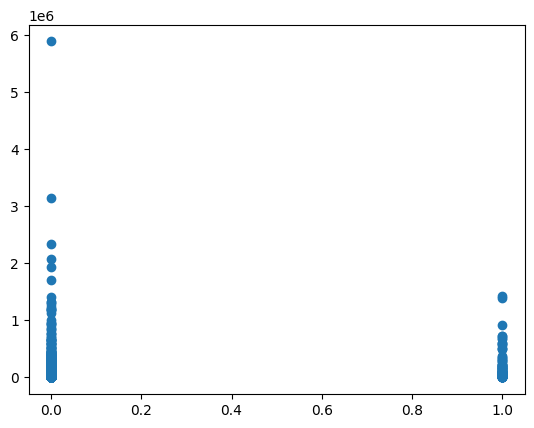

In [5]:
plt.scatter(datos["yngkid"], mco.resid**2)

In [6]:
 mco.model.exog

array([[1.000e+00, 3.438e+03, 1.200e+01, 3.200e+01, 1.024e+03, 0.000e+00],
       [1.000e+00, 5.020e+03, 1.400e+01, 3.100e+01, 9.610e+02, 0.000e+00],
       [1.000e+00, 2.815e+03, 1.700e+01, 4.400e+01, 1.936e+03, 0.000e+00],
       ...,
       [1.000e+00, 1.851e+03, 1.200e+01, 3.700e+01, 1.369e+03, 0.000e+00],
       [1.000e+00, 1.961e+03, 1.700e+01, 5.400e+01, 2.916e+03, 0.000e+00],
       [1.000e+00, 2.363e+03, 1.600e+01, 3.000e+01, 9.000e+02, 1.000e+00]])

In [7]:

import statsmodels.stats.api as sms

#GOLDFELD-QUANDT (Muestras Pequeñas)
GQ=sms.het_goldfeldquandt(y, sm.add_constant(datos["totwrk"]), split=1/3, drop=1/3)
print("Goldfeld Quandt: ", GQ)


Goldfeld Quandt:  (1.269064118450339, 0.03463196606346902, 'increasing')


In [8]:
y

0      3113
1      2920
2      2670
3      3083
4      3448
       ... 
701    2985
702    3520
703    3510
704    2970
705    2970
Name: sleep, Length: 706, dtype: int64

In [9]:
#BREUSH-PAGAN
BP=sms.het_breuschpagan(mco.resid, mco.model.exog)
print("Breush Pagan: ", BP)


Breush Pagan:  (8.82155799492389, 0.11639680587196029, 1.7714519624810057, 0.11644087001807633)


In [10]:
#WHITE
W=sms.het_white(mco.resid, mco.model.exog)
print("White: ", W)

White:  (22.795959353927522, 0.19855311726683972, 1.2734786831551437, 0.19800837119198622)


2. Usando los datos de **vote1** para el modelo $voteA = \beta_0 + \beta_1 \log(expendA) + \beta_2 \log(expendB) + \beta_3 prtystrA + \beta_4 democA+ u$, analizar la heteroscedasticidad del modelo usando los Test de Breush-Pagan y White.

In [11]:
dataWoo("vote1", description=True)
datos=dataWoo("vote1")
y=datos["voteA"]
X=datos[["lexpendA", "lexpendB", "prtystrA", "democA"]]

mco=sm.OLS(y, sm.add_constant(X)).fit()
mco.summary()



name of dataset: vote1
no of variables: 10
no of observations: 173

+----------+---------------------------------+
| variable | label                           |
+----------+---------------------------------+
| state    | state postal code               |
| district | congressional district          |
| democA   | =1 if A is democrat             |
| voteA    | percent vote for A              |
| expendA  | camp. expends. by A, $1000s     |
| expendB  | camp. expends. by B, $1000s     |
| prtystrA | % vote for president            |
| lexpendA | log(expendA)                    |
| lexpendB | log(expendB)                    |
| shareA   | 100*(expendA/(expendA+expendB)) |
+----------+---------------------------------+

From M. Barone and G. Ujifusa, The Almanac of American Politics, 1992.
Washington, DC: National Journal.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  voteA   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     169.2
Date:                Mon, 27 Nov 2023   Prob (F-statistic):           8.09e-58
Time:                        07:51:02   Log-Likelihood:                -593.20
No. Observations:                 173   AIC:                             1196.
Df Residuals:                     168   BIC:                             1212.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.6614      4.736      7.952      0.000      28.312      47.011
lexpendA       5.7793      0.392     14.750      0.000       5.006       6.553
lexpendB      -6.2378      0.397    -15.694      0.000      -7.022      -5.453
prtystrA       0.2519      0.071      3.534      0.001       0.111       0.393
democA         3.7929      1.407      2.697      0.008       1.016       6.570
==============================================================================
Omnibus:                        6.304   Durbin-Watson:                   1.525
Prob(Omnibus):                  0.043   Jarque-Bera (JB):                6.030
Skew:                           0.448   Prob(JB):                       0.0491
Kurtosis:                       3.182   Cond. No.                         429.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
#BREUSH-PAGAN
BP=sms.het_breuschpagan(mco.resid, mco.model.exog)
BP

(9.093356486631802,
 0.05880790411089989,
 2.3301128267408293,
 0.058057501107011425)

In [13]:
#WHITE
W=sms.het_white(mco.resid, mco.model.exog)
W

(31.101514031882214,
 0.00325826379881748,
 2.6807575729662894,
 0.00197332657011948)

3. Con la base de datos **gpa1**:
 - Estimar $colGPA = \beta_0 + \beta_1 hsGPA + \beta_2 ACT + \beta_3 skipped + \beta_4 PC + u$ y extraer los residuos.
 - Contrastar la posibilidad de heteroscedasticidad con el test de Breush-Pagan.
 - Analizar, con el test de Glejser, la dependencia funcional de la heteroscedasticidad con respecto a la variables que podrían provocarla.
 - Ajustar, según el método de Mínimos Cuadrados Ponderados, el modelo con la corrección de heteroscedasticidad.

In [14]:
dataWoo("gpa1", description=True)
datos=dataWoo("gpa1")
y=datos["colGPA"]
X=datos[["hsGPA", "ACT", "skipped", "PC"]]

mco=sm.OLS(y, sm.add_constant(X)).fit()
mco.summary()


name of dataset: gpa1
no of variables: 29
no of observations: 141

+----------+--------------------------------+
| variable | label                          |
+----------+--------------------------------+
| age      | in years                       |
| soph     | =1 if sophomore                |
| junior   | =1 if junior                   |
| senior   | =1 if senior                   |
| senior5  | =1 if fifth year senior        |
| male     | =1 if male                     |
| campus   | =1 if live on campus           |
| business | =1 if business major           |
| engineer | =1 if engineering major        |
| colGPA   | MSU GPA                        |
| hsGPA    | high school GPA                |
| ACT      | 'achievement' score            |
| job19    | =1 if job <= 19 hours          |
| job20    | =1 if job >= 20 hours          |
| drive    | =1 if drive to campus          |
| bike     | =1 if bicycle to campus        |
| walk     | =1 if walk to campus           |
| voluntr  | 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 colGPA   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     11.90
Date:                Mon, 27 Nov 2023   Prob (F-statistic):           2.55e-08
Time:                        07:51:02   Log-Likelihood:                -39.098
No. Observations:                 141   AIC:                             88.20
Df Residuals:                     136   BIC:                             102.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3565      0.328      4.142      0.000       0.709       2.004
hsGPA          0.4130      0.092      4.468      0.000       0.230       0.596
ACT            0.0133      0.010      1.278      0.204      -0.007       0.034
skipped       -0.0710      0.026     -2.706      0.008      -0.123      -0.019
PC             0.1244      0.057      2.171      0.032       0.011       0.238
==============================================================================
Omnibus:                        1.756   Durbin-Watson:                   1.875
Prob(Omnibus):                  0.416   Jarque-Bera (JB):                1.403
Skew:                          -0.031   Prob(JB):                        0.496
Kurtosis:                       2.515   Cond. No.                         300.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:

#BREUSH-PAGAN
BP=sms.het_breuschpagan(mco.resid, mco.model.exog)
BP

(11.874470062774039,
 0.01830956374340879,
 3.1266627314566744,
 0.016971725964339657)

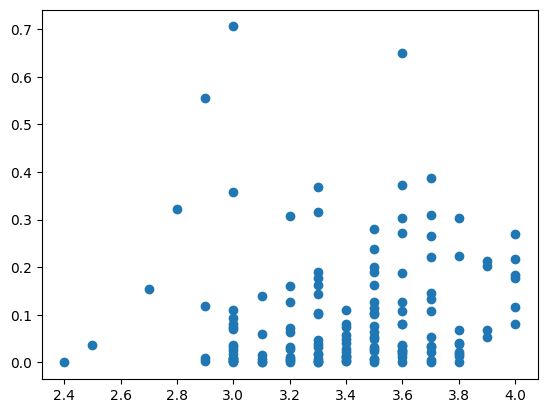

In [16]:
plt.scatter(datos["hsGPA"], mco.resid**2)

In [17]:



#GLEJSER
z=datos["hsGPA"]
for h in [-2, -1, -0.5, 0.5, 1, 2]:
    # |e| = delta_0 + delta_1 z^h + eps
    mcoaux=sm.OLS(abs(mco.resid), sm.add_constant(z**h)).fit()
    pval=mcoaux.pvalues[1]
    print("h: ", h, "-> pvalt:", pval, "R2: ", mcoaux.rsquared)



h:  -2 -> pvalt: 0.040258508949857226 R2:  0.029917986808139507
h:  -1 -> pvalt: 0.033353953278005444 R2:  0.03216061316383689
h:  -0.5 -> pvalt: 0.030411125324126802 R2:  0.03326672574358769
h:  0.5 -> pvalt: 0.025418944097517333 R2:  0.035422595100537246
h:  1 -> pvalt: 0.023319300360121354 R2:  0.03646280769629151
h:  2 -> pvalt: 0.019794714478545618 R2:  0.038445851497920014


$|e_i| = \alpha_0 + \alpha_1 z^2_i + v_i$

$w_i = \frac{1}{\sqrt{z_i^2}} = \frac{1}{z_i}$

In [18]:


mcp = sm.WLS(y, sm.add_constant(X), weights=1/z).fit()
mcp.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                 colGPA   R-squared:                       0.259
Model:                            WLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     11.87
Date:                Mon, 27 Nov 2023   Prob (F-statistic):           2.66e-08
Time:                        07:51:02   Log-Likelihood:                -38.597
No. Observations:                 141   AIC:                             87.19
Df Residuals:                     136   BIC:                             101.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4088      0.321      4.388      0.000       0.774       2.044
hsGPA          0.4041      0.089      4.518      0.000       0.227       0.581
ACT            0.0126      0.010      1.224      0.223      -0.008       0.033
skipped       -0.0736      0.026     -2.830      0.005      -0.125      -0.022
PC             0.1217      0.057      2.139      0.034       0.009       0.234
==============================================================================
Omnibus:                        0.782   Durbin-Watson:                   1.879
Prob(Omnibus):                  0.677   Jarque-Bera (JB):                0.833
Skew:                          -0.012   Prob(JB):                        0.659
Kurtosis:                       2.624   Cond. No.                         295.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
mco.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 colGPA   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     11.90
Date:                Mon, 27 Nov 2023   Prob (F-statistic):           2.55e-08
Time:                        07:51:26   Log-Likelihood:                -39.098
No. Observations:                 141   AIC:                             88.20
Df Residuals:                     136   BIC:                             102.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3565      0.328      4.142      0.000       0.709       2.004
hsGPA          0.4130      0.092      4.468      0.000       0.230       0.596
ACT            0.0133      0.010      1.278      0.204      -0.007       0.034
skipped       -0.0710      0.026     -2.706      0.008      -0.123      -0.019
PC             0.1244      0.057      2.171      0.032       0.011       0.238
==============================================================================
Omnibus:                        1.756   Durbin-Watson:                   1.875
Prob(Omnibus):                  0.416   Jarque-Bera (JB):                1.403
Skew:                          -0.031   Prob(JB):                        0.496
Kurtosis:                       2.515   Cond. No.                         300.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""